In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler

In [3]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.8/101.7 MB 3.1 MB/s eta 0:00:33
    --------------------------------------- 1.3/101.7 MB 3.1 MB/s eta 0:00:33
    --------------------------------------- 2.4/101.7 MB 3.4 MB/s eta 0:00:30
   - -------------------------------------- 3.4/101.7 MB 3.7 MB/s eta 0:00:27
   - -------------------------------------- 4.7/101.7 MB 4.1 MB/s eta 0:00:24
   -- ------------------------------------- 5.8/101.7 MB 4.2 MB/s eta 0:00:23
   -- ------------------------------------- 6.8/101.7 MB 4.5 MB/s eta 0:00:22
   --- ------------------------------------ 7.9/101.7 MB 4.3 MB/s eta 0:00:22
   --- ------------------------------------ 8.7/101.7 MB 4.4 MB/s eta 0:00:21
   --- ------------------------------------ 10.0/101.7 MB 4.5 MB/s eta 0:00:21
   ---- ----------------------------------- 11.5/101.7 MB 4.6 MB/s eta 0:00:2


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("XGBoost not installed. Run: pip install xgboost")

In [5]:
print("=" * 50)
print("STEP 1: Loading Data")
print("=" * 50)
 
df = pd.read_csv("chicago_taxi_train.csv")
print(f"Raw shape: {df.shape}")
print(df.head())
print("\nColumn dtypes:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())

STEP 1: Loading Data
Raw shape: (31694, 18)
    TRIP_START_TIMESTAMP     TRIP_END_TIMESTAMP  TRIP_START_HOUR  \
0  05/17/2022 7:15:00 AM  05/17/2022 7:45:00 AM             7.25   
1  05/17/2022 5:15:00 PM  05/17/2022 5:30:00 PM            17.25   
2  05/17/2022 5:15:00 PM  05/17/2022 5:30:00 PM            17.25   
3  05/17/2022 6:00:00 PM  05/17/2022 7:00:00 PM            18.00   
4  05/17/2022 5:00:00 PM  05/17/2022 5:30:00 PM            17.00   

   TRIP_SECONDS  TRIP_MILES  TRIP_SPEED  PICKUP_CENSUS_TRACT  \
0          2341        2.57         4.0                  NaN   
1          1074        1.18         4.0                  NaN   
2          1173        1.29         4.0         1.703132e+10   
3          3360        3.70         4.0         1.703132e+10   
4          1044        1.15         4.0         1.703132e+10   

   DROPOFF_CENSUS_TRACT  PICKUP_COMMUNITY_AREA  DROPOFF_COMMUNITY_AREA   FARE  \
0                   NaN                    NaN                    17.0  31.99   


In [6]:
print("\n" + "=" * 50)
print("STEP 2: Cleaning & Feature Engineering")
print("=" * 50)
 


STEP 2: Cleaning & Feature Engineering


In [8]:
col_map = {
    "Trip Miles": "TRIP_MILES",
    "Trip Seconds": "TRIP_SECONDS",
    "Fare": "FARE",
}
df.rename(columns={k: v for k, v in col_map.items() if k in df.columns}, inplace=True)
 

In [9]:
if "TRIP_SPEED" not in df.columns and "TRIP_MILES" in df.columns and "TRIP_SECONDS" in df.columns:
    df["TRIP_SPEED"] = df["TRIP_MILES"] / (df["TRIP_SECONDS"] / 3600 + 1e-6)

In [10]:
f = df[df["TRIP_MILES"] > 0]
df = df[df["TRIP_SECONDS"] > 0]
df = df[df["FARE"] > 0]
df = df[df["FARE"] < 200]        # Remove extreme outliers (likely data errors)
df = df[df["TRIP_MILES"] < 100] 

In [11]:
df["COST_PER_MILE"] = df["FARE"] / (df["TRIP_MILES"] + 1e-6)
 
# Trip duration in minutes (more interpretable than raw seconds)
df["TRIP_MINUTES"] = df["TRIP_SECONDS"] / 60
 
# Flag short vs long trips
df["IS_SHORT_TRIP"] = (df["TRIP_MILES"] < 2).astype(int)
 
# Parse pickup hour / day-of-week from timestamp if available
if "Trip Start Timestamp" in df.columns or "trip_start_timestamp" in df.columns:
    ts_col = "Trip Start Timestamp" if "Trip Start Timestamp" in df.columns else "trip_start_timestamp"
    df[ts_col] = pd.to_datetime(df[ts_col], errors="coerce")
    df["PICKUP_HOUR"] = df[ts_col].dt.hour
    df["DAY_OF_WEEK"] = df[ts_col].dt.dayofweek
    df["IS_RUSH_HOUR"] = df["PICKUP_HOUR"].apply(lambda h: 1 if h in [7, 8, 9, 17, 18, 19] else 0)
    df["IS_WEEKEND"] = (df["DAY_OF_WEEK"] >= 5).astype(int)
    time_features = ["PICKUP_HOUR", "DAY_OF_WEEK", "IS_RUSH_HOUR", "IS_WEEKEND"]
else:
    time_features = []
    print("No timestamp column found — skipping time-based features.")
 
print(f"Clean dataset shape: {df.shape}")
print(df.describe())

No timestamp column found — skipping time-based features.
Clean dataset shape: (31694, 21)
       TRIP_START_HOUR  TRIP_SECONDS    TRIP_MILES    TRIP_SPEED  \
count     31694.000000  31694.000000  31694.000000  31694.000000   
mean         14.185635   1319.796397      8.289463     20.256544   
std           5.159454    928.932873      7.265672     11.110390   
min           0.000000     60.000000      0.500000      4.000000   
25%          10.500000    548.000000      1.720000     11.000000   
50%          14.750000   1081.000000      5.920000     17.600000   
75%          18.000000   1888.000000     14.500000     27.500000   
max          23.750000   7140.000000     68.120000     64.800000   

       PICKUP_CENSUS_TRACT  DROPOFF_CENSUS_TRACT  PICKUP_COMMUNITY_AREA  \
count         1.325900e+04          1.402300e+04           28477.000000   
mean          1.703153e+10          1.703140e+10              35.562138   
std           3.827747e+05          3.408106e+05              26.421367

In [12]:
base_features = ["TRIP_MILES", "TRIP_SECONDS", "TRIP_SPEED", "TRIP_MINUTES", "IS_SHORT_TRIP"]
features = base_features + time_features
target = "FARE"
 
# Keep only columns that exist
features = [f for f in features if f in df.columns]
print(f"\nFeatures used ({len(features)}): {features}")
 
X = df[features]
y = df[target]
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\nTrain size: {len(X_train)}, Test size: {len(X_test)}")
 


Features used (5): ['TRIP_MILES', 'TRIP_SECONDS', 'TRIP_SPEED', 'TRIP_MINUTES', 'IS_SHORT_TRIP']

Train size: 25355, Test size: 6339


In [13]:
print("\n" + "=" * 50)
print("STEP 3: Training Models")
print("=" * 50)
 
results = {}
 
def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    r2   = r2_score(y_te, preds)
    rmse = np.sqrt(mean_squared_error(y_te, preds))
    mae  = mean_absolute_error(y_te, preds)
    print(f"\n{name}")
    print(f"  R²   : {r2:.4f}")
    print(f"  RMSE : ${rmse:.2f}")
    print(f"  MAE  : ${mae:.2f}")
    return model, {"R2": r2, "RMSE": rmse, "MAE": mae}


STEP 3: Training Models


In [14]:
lr, lr_metrics = evaluate(
    "Linear Regression",
    LinearRegression(),
    X_train, y_train, X_test, y_test
)
results["Linear Regression"] = lr_metrics


Linear Regression
  R²   : 0.9563
  RMSE : $3.60
  MAE  : $1.20


In [15]:
rf, rf_metrics = evaluate(
    "Random Forest (100 trees)",
    RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    X_train, y_train, X_test, y_test
)
results["Random Forest"] = rf_metrics


Random Forest (100 trees)
  R²   : 0.9539
  RMSE : $3.69
  MAE  : $1.17


In [16]:
if XGBOOST_AVAILABLE:
    xgb, xgb_metrics = evaluate(
        "XGBoost",
        XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6,
                     random_state=42, verbosity=0),
        X_train, y_train, X_test, y_test
    )
    results["XGBoost"] = xgb_metrics


XGBoost
  R²   : 0.9556
  RMSE : $3.62
  MAE  : $1.15


In [17]:
print("\n" + "=" * 50)
print("STEP 4: Selecting Best Model")
print("=" * 50)
 
best_name = max(results, key=lambda k: results[k]["R2"])
best_model = {"Linear Regression": lr, "Random Forest": rf}.get(best_name)
if XGBOOST_AVAILABLE and best_name == "XGBoost":
    best_model = xgb
 
print(f"Best model: {best_name} (R² = {results[best_name]['R2']:.4f})")
 


STEP 4: Selecting Best Model
Best model: Linear Regression (R² = 0.9563)


In [18]:
bundle = {
    "model": best_model,
    "features": features,
    "model_name": best_name,
    "metrics": results[best_name],
}
with open("best_model.pkl", "wb") as f:
    pickle.dump(bundle, f)
 
print("Saved → best_model.pkl")

Saved → best_model.pkl



STEP 5: Generating Plots
Plot saved → static/model_comparison.png
Plot saved → static/feature_importance.png

Done! ✓

Final Summary:
  Linear Regression    → R²=0.9563  RMSE=$3.60  MAE=$1.20
  Random Forest        → R²=0.9539  RMSE=$3.69  MAE=$1.17
  XGBoost              → R²=0.9556  RMSE=$3.62  MAE=$1.15


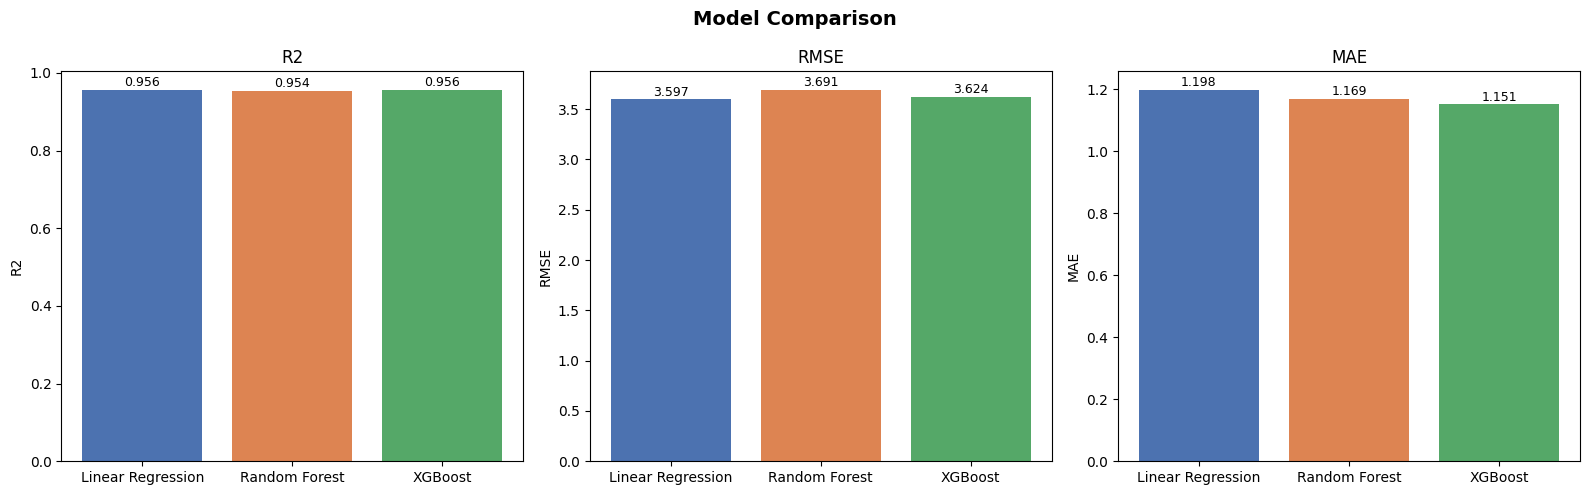

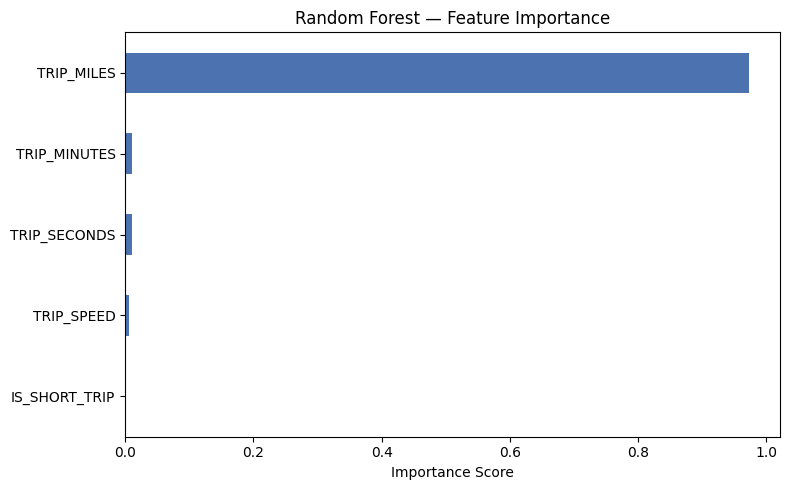

In [19]:
print("\n" + "=" * 50)
print("STEP 5: Generating Plots")
print("=" * 50)
 
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Model Comparison", fontsize=14, fontweight="bold")
 
metrics_list = ["R2", "RMSE", "MAE"]
for i, metric in enumerate(metrics_list):
    vals = [results[m][metric] for m in results]
    bars = axes[i].bar(results.keys(), vals, color=["#4C72B0", "#DD8452", "#55A868"][:len(results)])
    axes[i].set_title(metric)
    axes[i].set_ylabel(metric)
    for bar, val in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                     f"{val:.3f}", ha="center", fontsize=9)
 
plt.tight_layout()
plt.savefig("static/model_comparison.png", dpi=120)
print("Plot saved → static/model_comparison.png")
 
# Feature Importance (Random Forest)
if hasattr(rf, "feature_importances_"):
    fig2, ax2 = plt.subplots(figsize=(8, 5))
    importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)
    importances.plot(kind="barh", ax=ax2, color="#4C72B0")
    ax2.set_title("Random Forest — Feature Importance")
    ax2.set_xlabel("Importance Score")
    plt.tight_layout()
    plt.savefig("static/feature_importance.png", dpi=120)
    print("Plot saved → static/feature_importance.png")
 
print("\nDone! ✓")
print(f"\nFinal Summary:")
for name, m in results.items():
    print(f"  {name:20s} → R²={m['R2']:.4f}  RMSE=${m['RMSE']:.2f}  MAE=${m['MAE']:.2f}")